# How Learning Rate Shapes the Training Journey of a Neural Network
_A Deep Dive Using Fashion-MNIST_

## Introduction

In deep learning, no hyperparameter is as universally important—or universally troublesome—as the learning rate. It controls how fast or how cautiously our model updates its weights while learning.

Too small → training is painfully slow.
Too large → the model explodes or bounces around without learning.
Just right → fast convergence and good accuracy.

In this blog post, we explore the learning rate using a simple CNN trained on the Fashion-MNIST dataset. We’ll compare training curves, accuracy, and model stability across different learning rates.

## What Is Learning Rate?

The learning rate (LR) is a scalar coefficient 𝛼 used in gradient-based optimization:

$$
\theta_{t+1} = \theta_t - \alpha \nabla_{\theta} L(\theta_t)
$$

**Where:**

- $\theta$ = model parameters  
- $L$ = loss function  
- $\nabla_{\theta} L(\theta)$ = gradient  
- $\alpha$ = \text{learning rate}

**Why It Matters**

High LR → fast learning, but risk of divergence

Low LR → stable training, but slow and may get stuck

Optimal LR → smooth and efficient convergence

## Experiment Setup
**Dataset**

I used Fashion-MNIST: a collection of 28×28 grayscale images of clothing items (shirts, shoes, bags).

**Model**

A simple CNN:

- Conv2D(32) → ReLU
- Conv2D(64) → ReLU
- MaxPool
- Dropout(0.25)
- Dense(128) → ReLU
- Dropout(0.5)
- Dense(10 softmax)

**Learning Rates Tested**

I trained the same model using:

- 0.0001 (very small LR)
- 0.001 (typical LR)
- 0.01 (high LR)
- 0.1 (very high LR)

## Code

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train[..., None] / 255.
x_test = x_test[..., None] / 255.

# Function to build the CNN model
def build_model(lr):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

learning_rates = [0.0001, 0.001, 0.01, 0.1]
histories = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")
    model = build_model(lr)
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=10,
        batch_size=128,
        verbose=2
    )
    histories[lr] = history



Training with learning rate = 0.0001
Epoch 1/10
422/422 - 58s - 138ms/step - accuracy: 0.7113 - loss: 0.8667 - val_accuracy: 0.8192 - val_loss: 0.4844
Epoch 2/10
422/422 - 56s - 134ms/step - accuracy: 0.8198 - loss: 0.5170 - val_accuracy: 0.8543 - val_loss: 0.4133
Epoch 3/10
422/422 - 58s - 137ms/step - accuracy: 0.8437 - loss: 0.4506 - val_accuracy: 0.8690 - val_loss: 0.3717
Epoch 4/10
422/422 - 58s - 138ms/step - accuracy: 0.8572 - loss: 0.4115 - val_accuracy: 0.8742 - val_loss: 0.3451
Epoch 5/10
422/422 - 59s - 140ms/step - accuracy: 0.8664 - loss: 0.3818 - val_accuracy: 0.8838 - val_loss: 0.3268
Epoch 6/10
422/422 - 64s - 151ms/step - accuracy: 0.8737 - loss: 0.3615 - val_accuracy: 0.8862 - val_loss: 0.3103
Epoch 7/10
422/422 - 59s - 140ms/step - accuracy: 0.8789 - loss: 0.3431 - val_accuracy: 0.8937 - val_loss: 0.3027
Epoch 8/10
422/422 - 57s - 135ms/step - accuracy: 0.8839 - loss: 0.3287 - val_accuracy: 0.8973 - val_loss: 0.2896
Epoch 9/10
422/422 - 57s - 134ms/step - accuracy: 

## Plotting the Training Curves

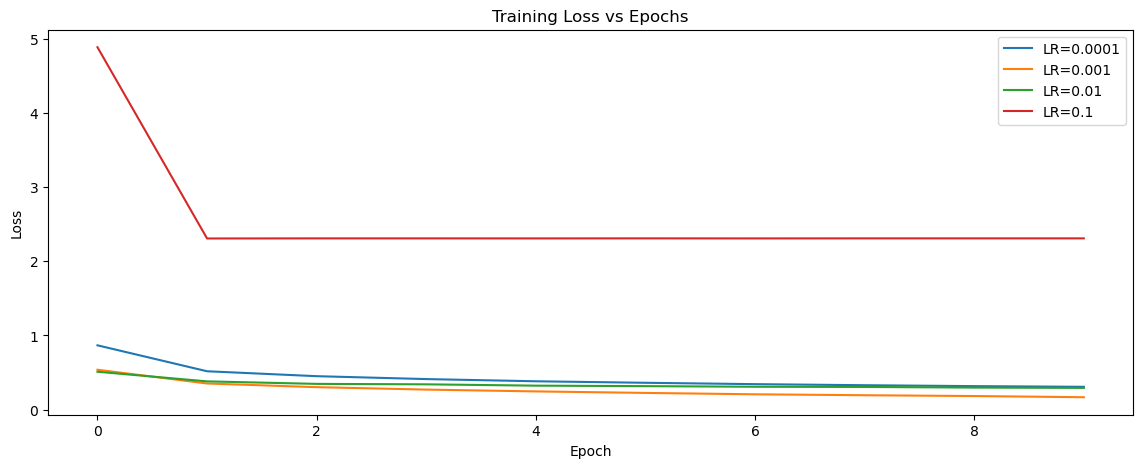

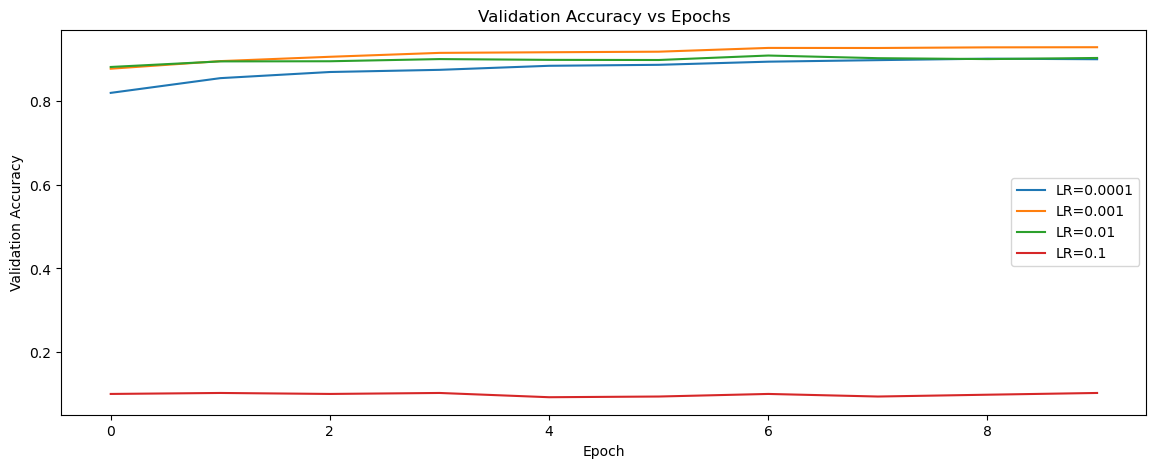

In [8]:
plt.figure(figsize=(14,5))
for lr, hist in histories.items():
    plt.plot(hist.history['loss'], label=f'LR={lr}')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
for lr, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f'LR={lr}')
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


## Results & Analysis

**LR = 0.0001 (Very Low)**

- Loss decreases slowly but steadily
- Validation accuracy improves gradually
- No instability
- Slight underfitting due to slow learning

**LR = 0.001 (Best Performer)**

- Smooth, stable loss curve
- Fast and consistent convergence
- Highest validation accuracy among all runs
- No spikes or divergence
 Best learning rate in this experiment

**LR = 0.01 (High)**

- Slightly faster loss reduction than 0.001 at first
- Validation accuracy is high and stable
- Not much instability in your actual plots
 Still a good LR — not unstable in your case

**LR = 0.1 (Too High)**

- Training loss starts very high and collapses into a constant plateau
- Validation accuracy stays extremely low (~10%)
- Model basically fails to learn anything
 Diverged / stuck — too large to train

## Key Insights

1. Learning rate heavily influences training stability and model performance.
- The experiments clearly show that changing the learning rate alters both how fast the model learns and whether it learns at all.

2. LR = 0.001 provides the best overall performance.
- Smooth loss reduction
- High validation accuracy
- No signs of divergence
- This makes it the optimal learning rate for this task.

3. LR = 0.0001 is stable but learns too slowly.

- Loss decreases steadily but very gradually
- Reaches good accuracy but slower than LR = 0.001
- Best used when extremely stable learning is needed

4. LR = 0.01 still performs well.

- Loss and accuracy curves are stable
- Only slightly worse than LR = 0.001
- Still a viable learning rate for this dataset/model

5. LR = 0.1 is too high and causes learning failure.

- Training loss spikes then becomes stuck
- Validation accuracy remains around random guessing (~10%)
- Strong evidence of divergence
- Model cannot optimize with such a large step size

## Conclusion

The experiment demonstrates that tuning the learning rate is crucial for effective neural network training. A moderate learning rate (0.001) provides the best balance of stability and speed, allowing the model to converge efficiently while maintaining high accuracy. Very low learning rates (0.0001) learn too slowly, while very high rates (0.1) destabilize the training process and prevent the model from learning altogether.